# Analysis of Routing Request Profiling Data


This notebook analyzes routing request profiling data from parallel QSim runs and router profiling logs. It loads the data, merges it based on request identifiers, and visualizes the relationships between request durations recorded by QSim and the router.

We see a clear correlation between blocking_recv durations in QSim and the preplanning horizon. There are some activities that have duration = 0. In this case, the former asynchronous requests get synchronous and the qsim waits for the router to respond immediately.

In [1]:

from pathlib import Path

import pandas as pd

from load2 import discover, read_aggregated_routing, read_router

In [2]:
root = Path("/Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct")

runs = discover(root)

# filter runs where run.run_id = "sim192_hor0_w4_r1_1pct"
runs = [r for r in runs if r.run_id == "sim192_hor0_w4_r1_1pct"]

print(runs)


[RunMeta(run_id='sim192_hor0_w4_r1_1pct', sim_thread_count=192, horizon=0, worker=4, routing_threads=1, pct=1, sim_path=PosixPath('/Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_sim'), server_paths=(ServerPath(server_number=0, path=PosixPath('/Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_server0')),))]


In [3]:
routing_data: dict[str, pd.DataFrame] = {}

for run in runs:
    print(f"Loading routing data for run {run.run_id}")
    data = read_aggregated_routing(run)
    data = data[data["request_uuid_u128"] != 0]
    routing_data[run.run_id] = data

Loading routing data for run sim192_hor0_w4_r1_1pct
Reading routing file: /Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_sim/instrument/routing_process_0.parquet
Reading parquet:  /Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_sim/instrument/routing_process_0.parquet
Reading routing file: /Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_sim/instrument/routing_process_1.parquet
Reading parquet:  /Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_sim/instrument/routing_process_1.parquet
Reading routing file: /Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_sim/instrument/routing_process_10.parquet
Reading parquet:  /Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_sim/

In [4]:
routing_data["sim192_hor0_w4_r1_1pct"].columns.values

array(['target', 'func_name', 'duration_ns', 'sim_time', 'person_id',
       'mode', 'rank', 'run_id', 'sim_thread_count', 'horizon', 'worker',
       'routing_threads', 'pct', 'process_id', 'timestamp_u128',
       'request_uuid_u128'], dtype=object)

# Load Router Data

In [5]:
router_data: dict[str, pd.DataFrame] = {}

for run in runs:
    print(f"Loading routing data for run {run.run_id}")
    data = read_router(run, commit_hash="a48eca7")
    router_data[run.run_id] = data

Loading routing data for run sim192_hor0_w4_r1_1pct
Reading routing profiling CSV: /Users/paulh/hlrn-cluster/rust-pt-routing/parallel-qsim-berlin/output/v6.4/1pct/sim192_hor0_w4_r1_1pct_server0/routing/a48eca7/routing-profiling-2026-03-24_15-05-15.csv


In [6]:
sample_run_id = "sim192_hor0_w4_r1_1pct"

router = router_data[sample_run_id]

qsim = routing_data[sample_run_id]
qsim = qsim[qsim["func_name"] == "blocking_recv"]

# qsim[qsim['request_uuid_u128'] == 2144459572868393109753598059720148573]

In [7]:
# print(router.dtypes)
# print(qsim.dtypes)
# router[router[("request_id_u128")] == 2144459570760002281211955421864966966]

In [8]:
# join on request_uuid_u128 in qsim and request_id in router
merged_df = pd.merge(
    qsim,
    router,
    left_on='request_uuid_u128',
    right_on='request_id_u128',
    how='inner'  # or 'left', 'right', 'outer' depending on your needs
)

# rename duration_ns_x to duration_ns_qsim and duration_ns_y to duration_ns_router
merged_df = merged_df.rename(columns={'duration_ns_x': 'duration_ns_qsim', 'duration_ns_y': 'duration_ns_router'})

merged_df

,target,func_name,duration_ns_qsim,sim_time,person_id,mode,rank,run_id,sim_thread_count,horizon,...,thread,now,departure_time,from,to,start,duration_ns_router,travel_time_s,server_id,request_id_u128
0,rust_qsim::simulation::agents::agent_logic,blocking_recv,5370431,19070,berlin_dc6210de,,100,sim192_hor0_w4_r1_1pct,192,0,...,0,19070,19070,-4662739,-4378528#6,305479118332493,4739402,2101,0,2145070707342895778363483226826796170
1,rust_qsim::simulation::agents::agent_logic,blocking_recv,10991941,19557,berlin_5a050119,,100,sim192_hor0_w4_r1_1pct,192,0,...,0,19557,19557,151618249#1,-4796865#0,305480010657052,10295176,4114,0,2145070708421310479471683374625167864
2,rust_qsim::simulation::agents::agent_logic,blocking_recv,11504112,19687,berlin_e7e6d51a,,100,sim192_hor0_w4_r1_1pct,192,0,...,0,19687,19687,-785567931#1,-1089694871,305480222438380,10515237,3006,0,2145070708677598935923912121100108019
3,rust_qsim::simulation::agents::agent_logic,blocking_recv,14901018,20196,berlin_ddec498b,,100,sim192_hor0_w4_r1_1pct,192,0,...,0,20196,20196,38198021#0,-328440053,305481428009746,14132236,3708,0,2145070710135507338425470044366158228
4,rust_qsim::simulation::agents::agent_logic,blocking_recv,2537775,20842,berlin_e4983621,,100,sim192_hor0_w4_r1_1pct,192,0,...,0,20842,20842,-1065317950#2,-4596983,305482638163524,2028845,2578,0,2145070711598315585943898773614457544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60595,rust_qsim::simulation::agents::agent_logic,blocking_recv,3610531,77096,berlin_9ef050d1,,99,sim192_hor0_w4_r1_1pct,192,0,...,0,77096,77096,-1118594766,-4394943#0,305684992233691,386251,207,0,2145070956225717791612860258783603943
60596,rust_qsim::simulation::agents::agent_logic,blocking_recv,5626272,77277,berlin_3663e00f,,99,sim192_hor0_w4_r1_1pct,192,0,...,0,77277,77277,-1119621920#0,-589691163#0,305685117517731,433251,254,0,2145070956374363427306775472233053650
60597,rust_qsim::simulation::agents::agent_logic,blocking_recv,8154629,77832,berlin_3663e00f,,99,sim192_hor0_w4_r1_1pct,192,0,...,0,77832,77832,-589691163#0,-1119621920#0,305685466519169,429900,254,0,2145070956792689260377801368028131286
60598,rust_qsim::simulation::agents::agent_logic,blocking_recv,668139,77996,berlin_9ef050d1,,99,sim192_hor0_w4_r1_1pct,192,0,...,0,77996,77996,-4394943#0,-1118594766,305685552961070,446880,207,0,2145070956906289625298132730227699273


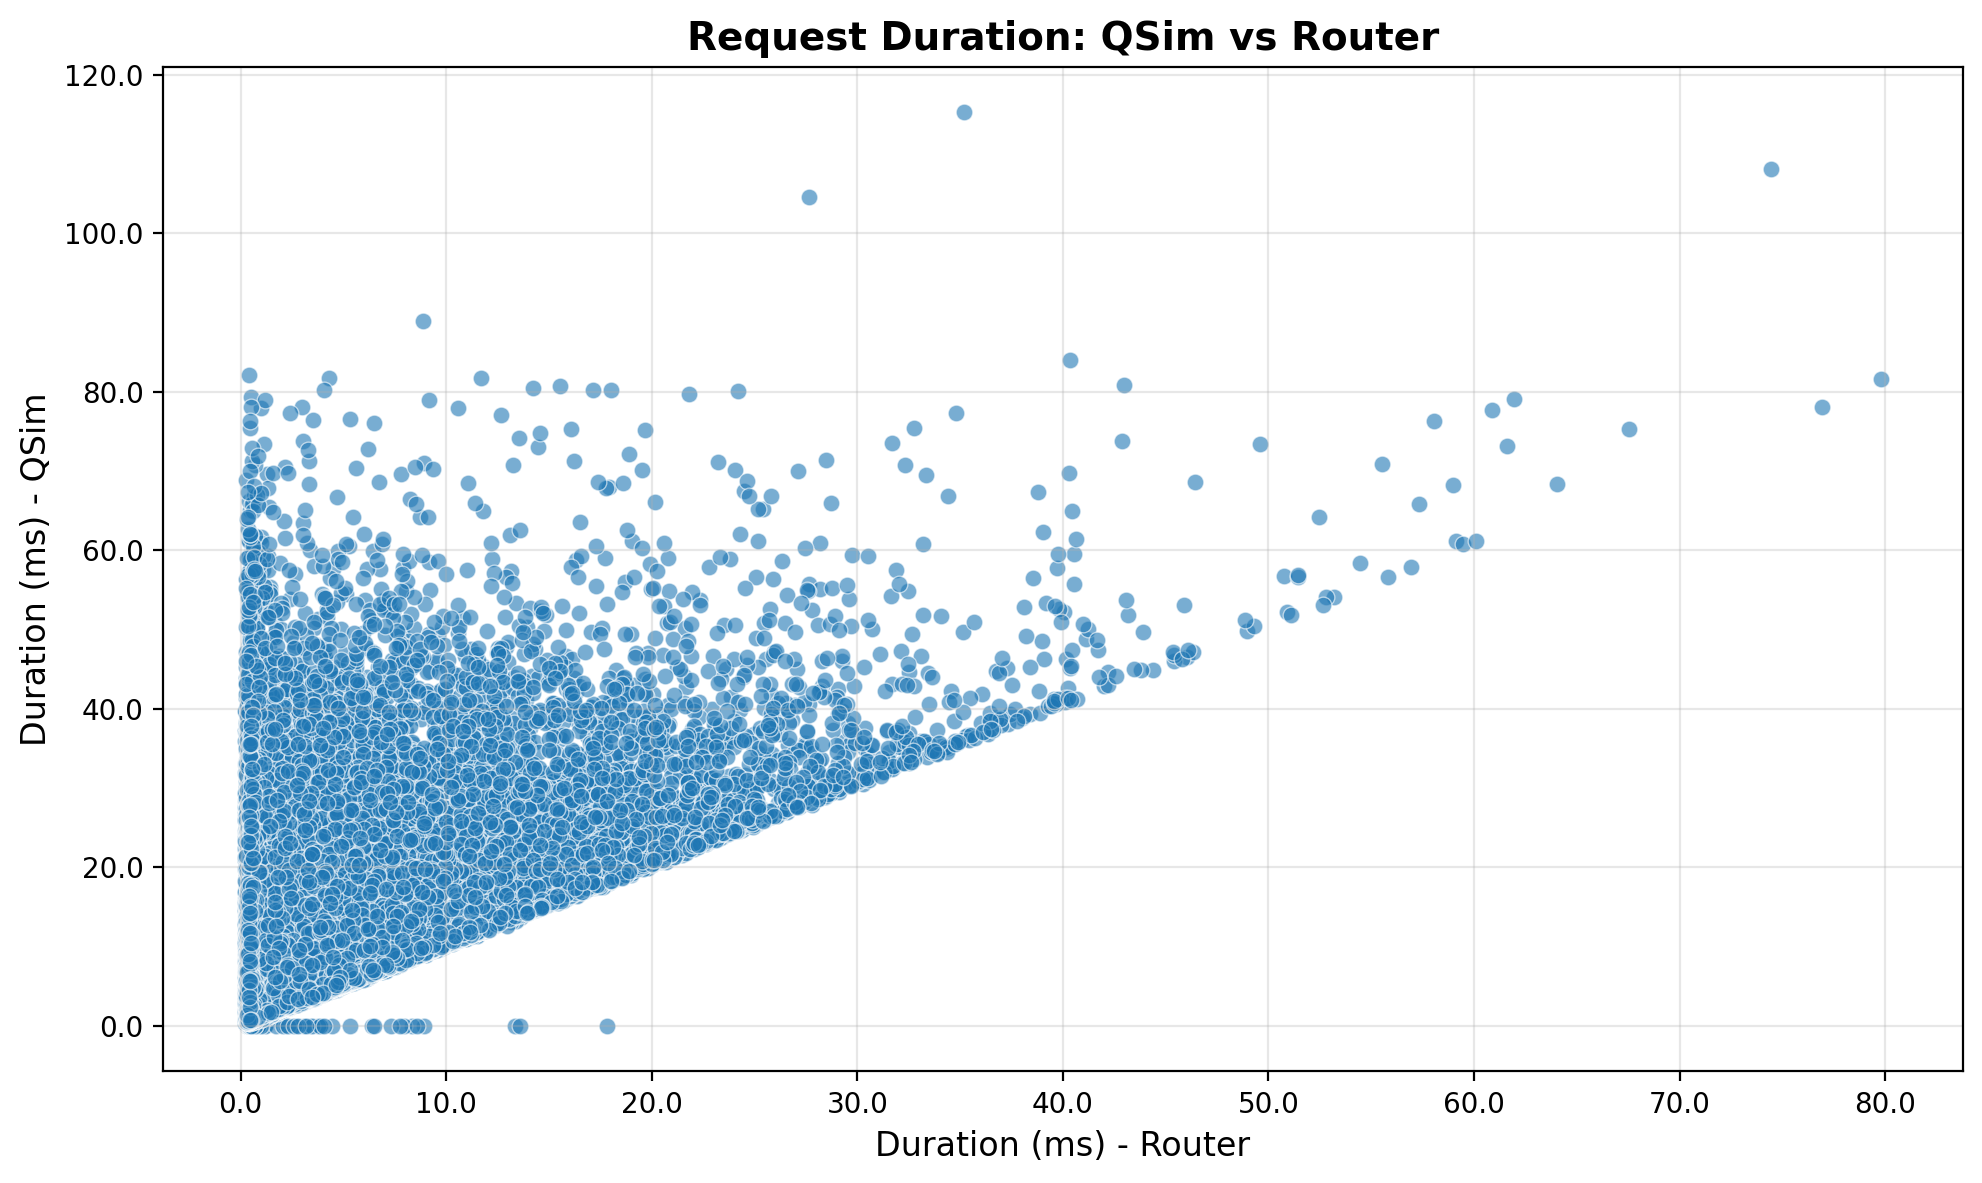

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

# Create scatter plot with scaled values (ns to ms)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='duration_ns_router', y='duration_ns_qsim', alpha=0.6)

# Scale axes to milliseconds
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x / 1e6:.1f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y / 1e6:.1f}'))

# Add title and labels
plt.title('Request Duration: QSim vs Router', fontsize=14, fontweight='bold')
plt.xlabel('Duration (ms) - Router', fontsize=12)
plt.ylabel('Duration (ms) - QSim', fontsize=12)

# Show grid for easier reading
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

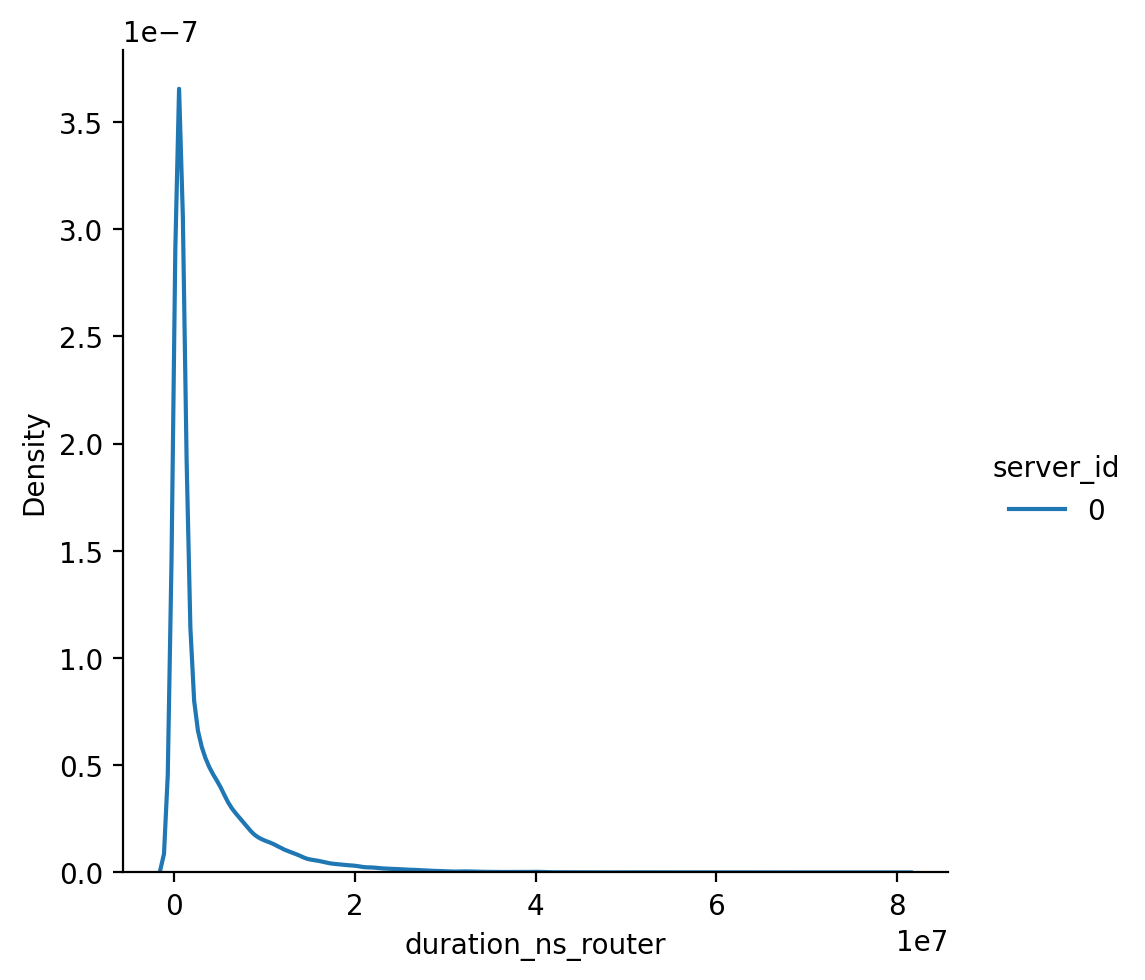

In [10]:
# plot distribution of duration_ns_qsim and duration_ns_router with seaborn into one plot
sns.displot(merged_df, x="duration_ns_router", hue="server_id", kind="kde")


# Group QSim data for the insights

In [11]:
# Pivot the data to get duration_ns and sim_time for each func_name
# result = routing_data[sample_run_id].pivot_table(
#     index='request_uuid_u128',
#     columns='func_name',
#     values=['duration_ns', 'sim_time'],
#     aggfunc='min'
#     # aggfunc='first'  # Use 'first' since there should be exactly one row per func_name
# )
#
# # Flatten the multi-level column names
# result.columns = [f'{col[1]}_{col[0]}' for col in result.columns]
#
# # Reset index to make request_uuid_u128 a regular column
# result = result.reset_index()
#
# result

In [12]:
funcs = [
    "call_router",
    "blocking_recv",
    "replace_next_trip",
    "replace_route",
]

routing_data[sample_run_id] = routing_data[sample_run_id][routing_data[sample_run_id]["request_uuid_u128"] != 0]

df4 = routing_data[sample_run_id][routing_data[sample_run_id]["func_name"].isin(funcs)]

counts = (
    df4.groupby(["request_uuid_u128", "func_name"])
    .size()
    .unstack(fill_value=0)
)

# Check that every UUID has exactly one of each function
bad = counts[(counts != 1).any(axis=1)]
if not bad.empty:
    raise ValueError(
        f"Some request_uuid_u128 do not have exactly one row per func_name:\n{bad}"
    )

pivot = (
    df4
    .set_index(["request_uuid_u128", "func_name"])
    [["duration_ns", "sim_time"]]
    .unstack("func_name")
)

pivot.columns = [
    f"{metric}_{func}" for metric, func in pivot.columns
]

wide_qsim = pivot.reset_index()

wide_qsim["real_horizon"] = wide_qsim['sim_time_replace_route'] - wide_qsim['sim_time_call_router']

wide_qsim

,request_uuid_u128,duration_ns_blocking_recv,duration_ns_call_router,duration_ns_replace_next_trip,duration_ns_replace_route,sim_time_blocking_recv,sim_time_call_router,sim_time_replace_next_trip,sim_time_replace_route,real_horizon
0,2145070701853160683119239678159499865,108038020,80520,68660,108141891,300,300,300,300,0
1,2145070702055051346711969658954452100,61154409,37530,80060,61244239,1564,1564,1564,1564,0
2,2145070702230347897083577851953702975,4168998,18140,2560,4176158,3190,3190,3190,3190,0
3,2145070702472162632360118305754545323,10420340,24580,20630,10445620,4832,4832,4832,4832,0
4,2145070702588198224701056147682305842,12963085,20640,7740,12975725,5539,5539,5539,5539,0
...,...,...,...,...,...,...,...,...,...,...
60595,2145070959932215619971193500640908957,2526294,23600,53809,2585223,91706,91706,91706,91706,0
60596,2145070960077298195065419158182918359,29138116,31610,79660,29230556,92946,92946,92946,92946,0
60597,2145070960136562416866635552130485750,966607,21020,23770,993827,93361,93361,93361,93361,0
60598,2145070960181251666422054395921838056,24378318,17980,89560,24476748,94173,94173,94173,94173,0


In [13]:
merged_df_wide = pd.merge(
    wide_qsim,
    router,
    left_on='request_uuid_u128',
    right_on='request_id_u128',
    how='inner'  # or 'left', 'right', 'outer' depending on your needs
)

merged_df_wide

,request_uuid_u128,duration_ns_blocking_recv,duration_ns_call_router,duration_ns_replace_next_trip,duration_ns_replace_route,sim_time_blocking_recv,sim_time_call_router,sim_time_replace_next_trip,sim_time_replace_route,real_horizon,thread,now,departure_time,from,to,start,duration_ns,travel_time_s,server_id,request_id_u128
0,2145070701853160683119239678159499865,108038020,80520,68660,108141891,300,300,300,300,0,0,300,300,-1101010197,-182600492#0,305474606558098,74451750,857,0,2145070701853160683119239678159499865
1,2145070702055051346711969658954452100,61154409,37530,80060,61244239,1564,1564,1564,1564,0,0,1564,1564,82654059#0,-4999747#2,305474745306991,59105380,2956,0,2145070702055051346711969658954452100
2,2145070702230347897083577851953702975,4168998,18140,2560,4176158,3190,3190,3190,3190,0,0,3190,3190,-561952683,-561952683,305474890041949,2462516,0,0,2145070702230347897083577851953702975
3,2145070702472162632360118305754545323,10420340,24580,20630,10445620,4832,4832,4832,4832,0,0,4832,4832,-4999747#2,82654059#0,305475091122410,7862620,4781,0,2145070702472162632360118305754545323
4,2145070702588198224701056147682305842,12963085,20640,7740,12975725,5539,5539,5539,5539,0,0,5539,5539,-24205468#3,69212650#1,305475186812603,10833618,198,0,2145070702588198224701056147682305842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60595,2145070959932215619971193500640908957,2526294,23600,53809,2585223,91706,91706,91706,91706,0,0,91706,91706,-34886812#0,-574070499,305688056250518,1827082,879029,0,2145070959932215619971193500640908957
60596,2145070960077298195065419158182918359,29138116,31610,79660,29230556,92946,92946,92946,92946,0,0,92946,92946,-133408632,-308079227,305688175690368,28023783,15713,0,2145070960077298195065419158182918359
60597,2145070960136562416866635552130485750,966607,21020,23770,993827,93361,93361,93361,93361,0,0,93361,93361,162949355,-1044264577,305688225142603,324041,105493,0,2145070960136562416866635552130485750
60598,2145070960181251666422054395921838056,24378318,17980,89560,24476748,94173,94173,94173,94173,0,0,94173,94173,-1123734499,-750925431,305688262571870,22951964,13257,0,2145070960181251666422054395921838056


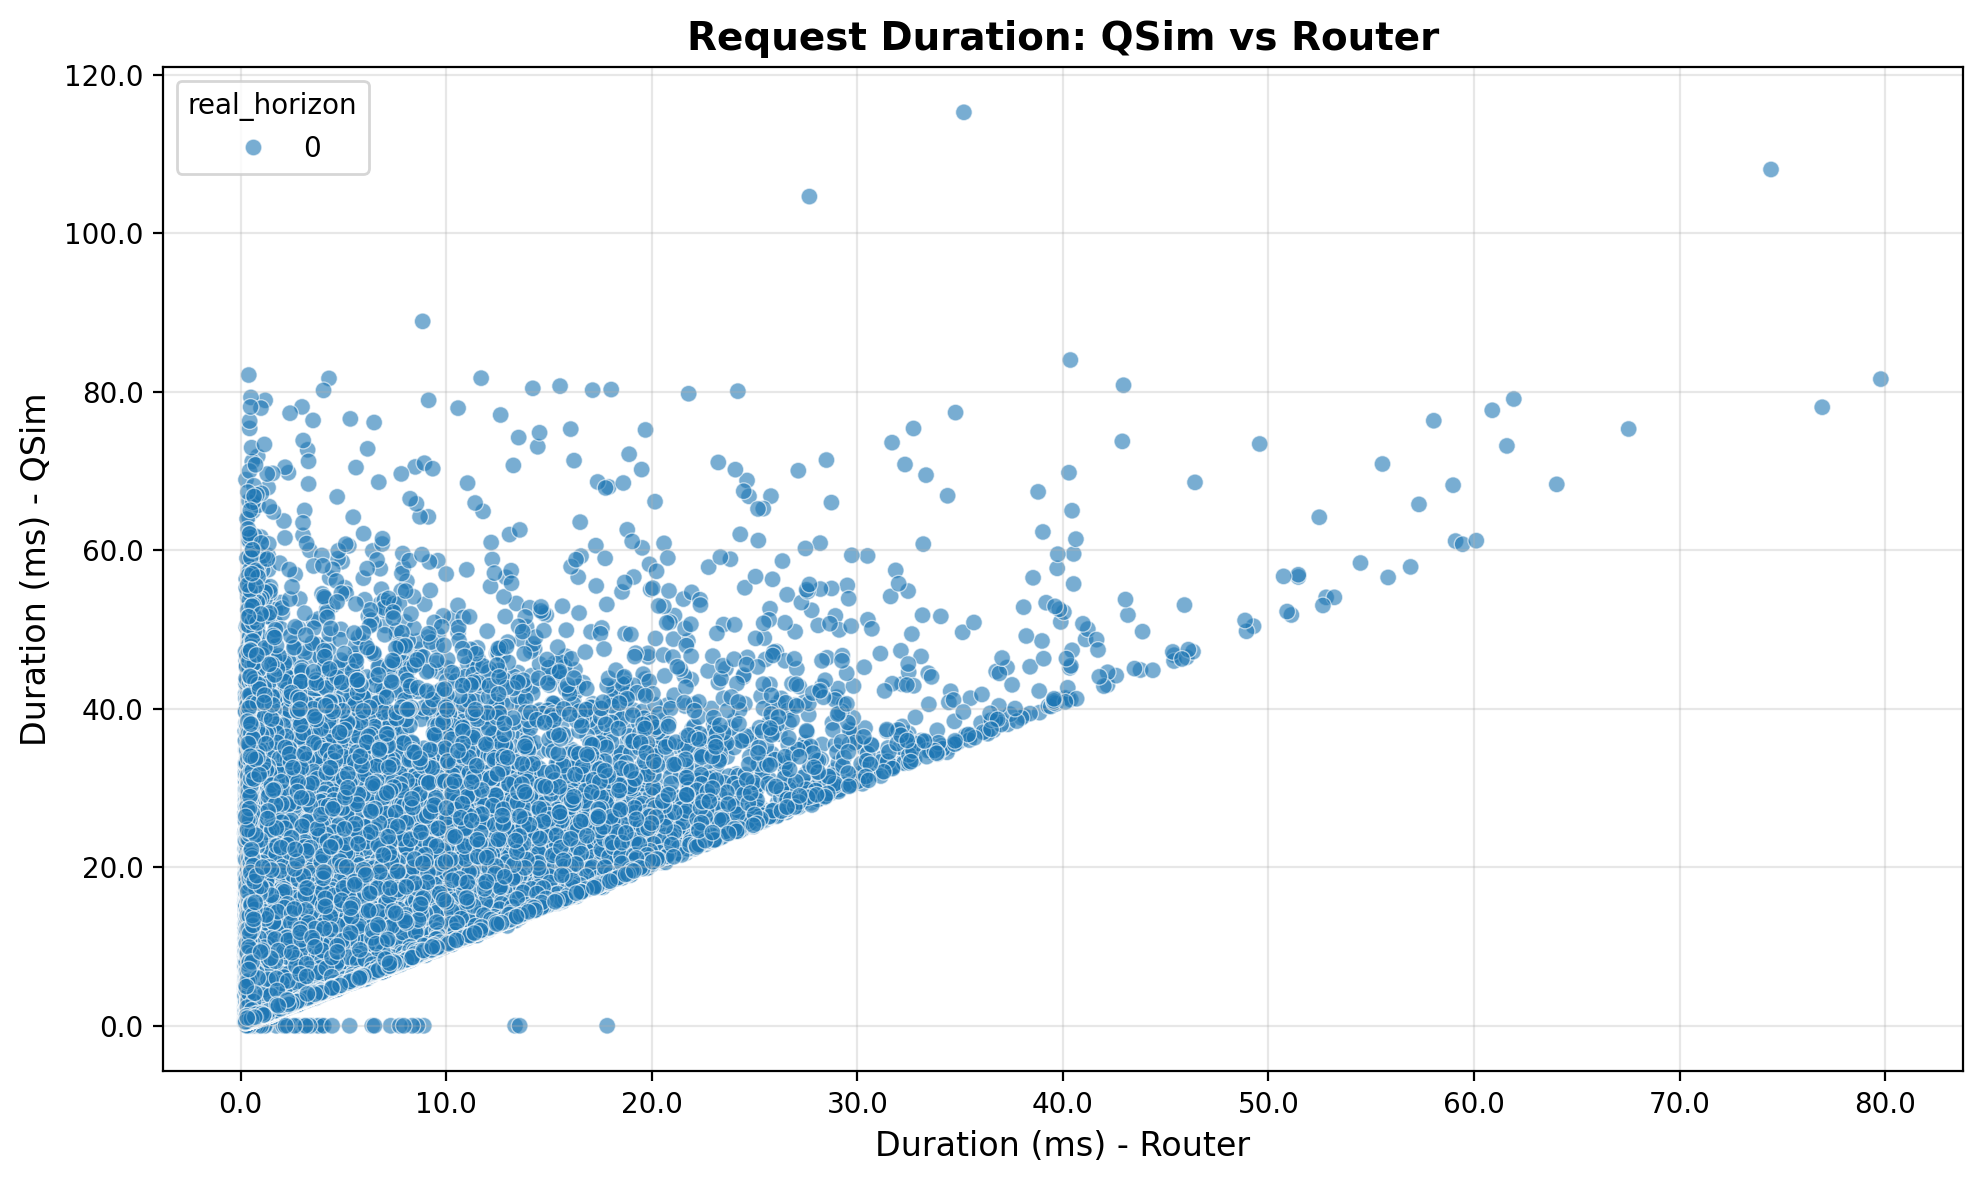

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create scatter plot with scaled values (ns to ms)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df_wide, x='duration_ns', y='duration_ns_blocking_recv', hue="real_horizon", alpha=0.6)

# Scale axes to milliseconds
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x / 1e6:.1f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y / 1e6:.1f}'))

# Add title and labels
plt.title('Request Duration: QSim vs Router', fontsize=14, fontweight='bold')
plt.xlabel('Duration (ms) - Router', fontsize=12)
plt.ylabel('Duration (ms) - QSim', fontsize=12)

# Show grid for easier reading
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
sum = merged_df_wide["duration_ns_blocking_recv"].sum()
count = merged_df_wide["duration_ns_blocking_recv"].count()
print("sum:", sum)
print("count:", count)
print(f"Average duration_ns_blocking_recv: {sum / count / 1e6:.2f} ms")

sum: 618872477413
count: 60600
Average duration_ns_blocking_recv: 10.21 ms


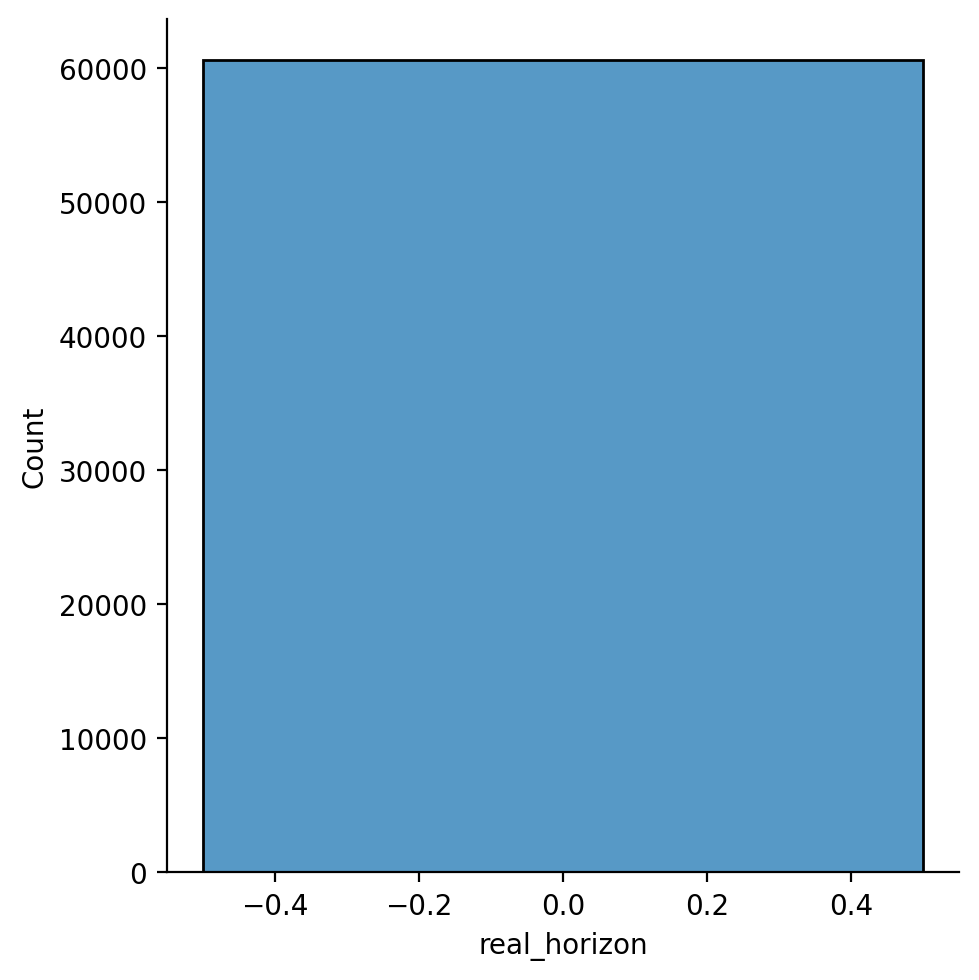

In [16]:
# plot distribution of real_horizon
sns.displot(merged_df_wide, x="real_horizon")


In [17]:
merged_df_wide[merged_df_wide["real_horizon"] == 0].count()

request_uuid_u128                60600
duration_ns_blocking_recv        60600
duration_ns_call_router          60600
duration_ns_replace_next_trip    60600
duration_ns_replace_route        60600
sim_time_blocking_recv           60600
sim_time_call_router             60600
sim_time_replace_next_trip       60600
sim_time_replace_route           60600
real_horizon                     60600
thread                           60600
now                              60600
departure_time                   60600
from                             60600
to                               60600
start                            60600
duration_ns                      60600
travel_time_s                    60600
server_id                        60600
request_id_u128                  60600
dtype: int64

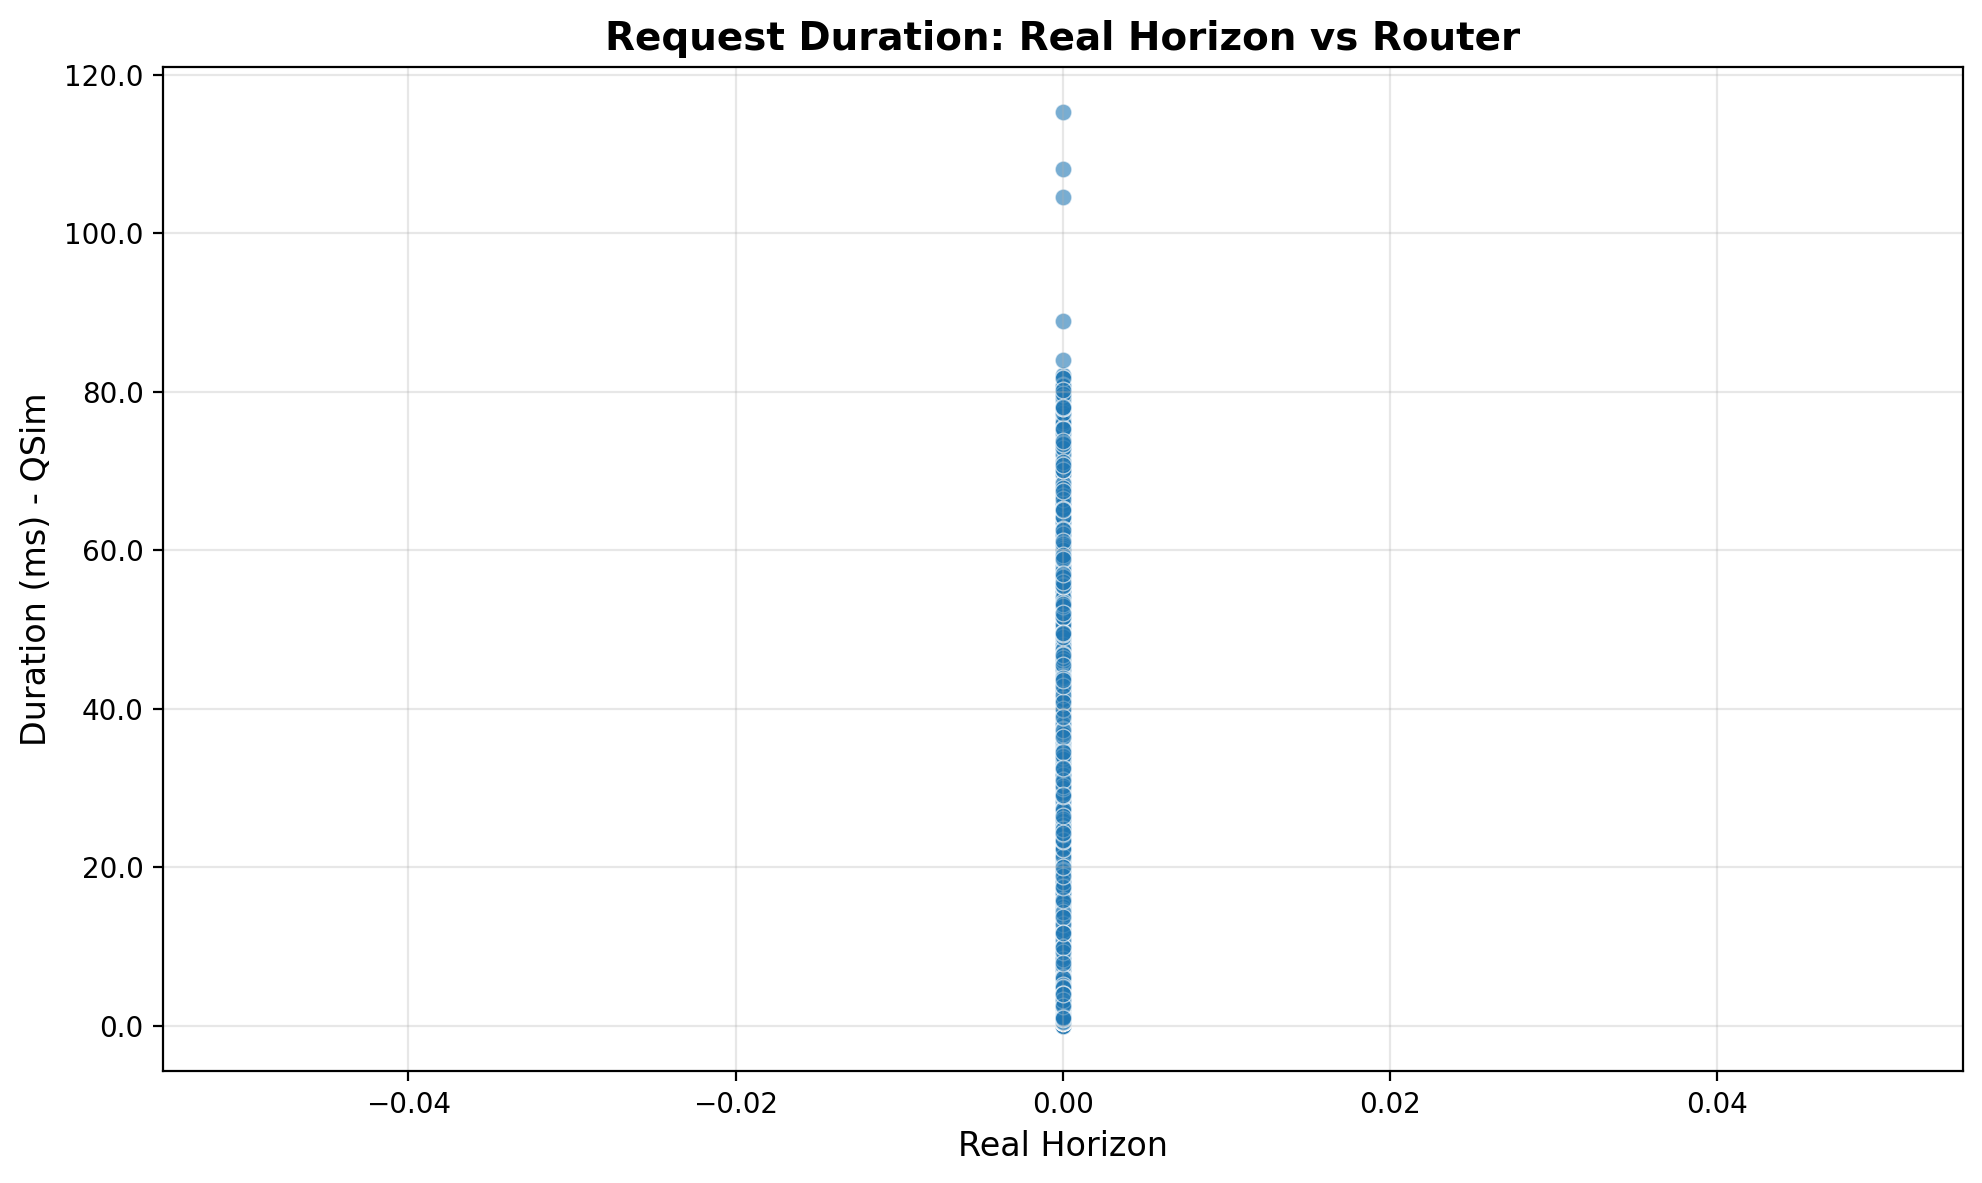

In [18]:
# Create scatter plot with scaled values (ns to ms)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df_wide, x='real_horizon', y='duration_ns_blocking_recv', alpha=0.6)

# Scale axes to milliseconds
ax = plt.gca()
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y / 1e6:.1f}'))

# Add title and labels
plt.title('Request Duration: Real Horizon vs Router', fontsize=14, fontweight='bold')
plt.xlabel('Real Horizon', fontsize=12)
plt.ylabel('Duration (ms) - QSim', fontsize=12)

# Show grid for easier reading
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Text(0.5694444444444446, 0.5, 'Density')

<Figure size 1000x600 with 0 Axes>

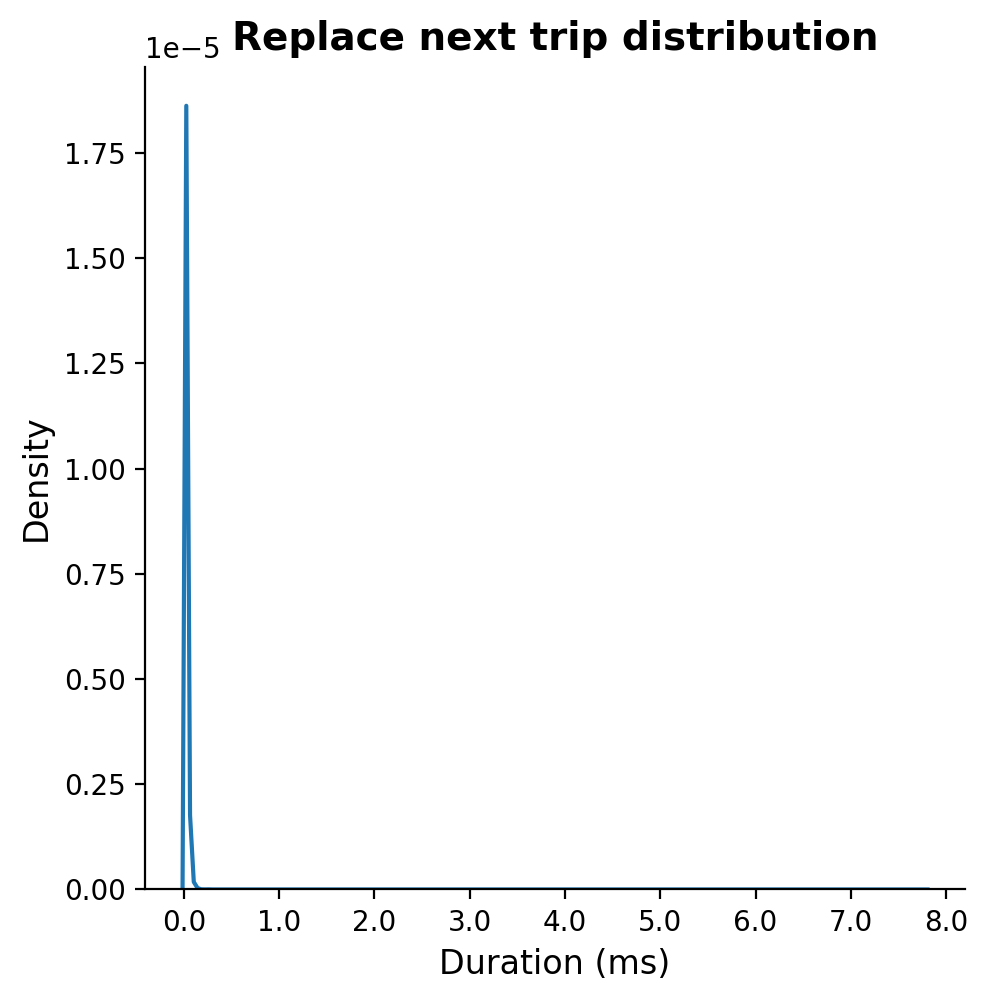

In [19]:
# plot distribution of duration_ns_replace_next_trip
# scale by 1/1e6 before
plt.figure(figsize=(10, 6))
sns.displot(merged_df_wide, x="duration_ns_replace_next_trip", kind="kde")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x / 1e6:.1f}'))
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y/1e6:.1f}'))

plt.title('Replace next trip distribution', fontsize=14, fontweight='bold')
plt.xlabel('Duration (ms)', fontsize=12)
plt.ylabel('Density', fontsize=12)


In [21]:
merged_df_wide[merged_df_wide["real_horizon"] > 0]

,request_uuid_u128,duration_ns_blocking_recv,duration_ns_call_router,duration_ns_replace_next_trip,duration_ns_replace_route,sim_time_blocking_recv,sim_time_call_router,sim_time_replace_next_trip,sim_time_replace_route,real_horizon,thread,now,departure_time,from,to,start,duration_ns,travel_time_s,server_id,request_id_u128
3,2144972917347894163258830885835223243,3000,23380,79860,88530,4830,4619,4830,4830,211,0,4619,4830,-4999747#2,82654059#0,213731065853374,7706999,4783,0,2144972917347894163258830885835223243
8,2144972917604179591028736405985563157,3520,14500,85870,97260,6467,6167,6467,6467,300,0,6167,6467,-1085364645#0,-25868744,213731277242618,534302,720,0,2144972917604179591028736405985563157
9,2144972917630787524850053947038595856,3970,16860,4110,13380,6650,6350,6650,6650,300,0,6350,6650,168878751#0,-866884849#1,213731299057662,526471,367,0,2144972917630787524850053947038595856
45,2144972918961821624774912716384352360,1770,22740,51030,57740,14686,14386,14686,14686,300,0,14386,14686,-894555414,-20553068#1,213732399984875,1838444,2569,0,2144972918961821624774912716384352360
63,2144972919388532890483653341510236211,2490,20040,25120,34310,15980,15761,15980,15980,219,0,15761,15980,-1056267275,-1066895445,213732753321753,1195743,1356,0,2144972919388532890483653341510236211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60563,2144973175905653289003254585594206633,3030,16430,4360,14110,85090,84790,85090,85090,300,0,84790,85090,-876051946#4,-36852342#0,213944938958549,289481,223,0,2144973175905653289003254585594206633
60565,2144973175910532343711566448567105186,2570,11830,4830,35041,85155,84855,85155,85155,300,0,84855,85155,5025930,-1106386456,213944942643508,234811,24,0,2144973175910532343711566448567105186
60569,2144973175956478905591950001689952398,3550,9780,4050,12120,85735,85435,85735,85735,300,0,85435,85735,-512735322#2,-587454495,213944980128779,237831,223,0,2144973175956478905591950001689952398
60587,2144973176238120875911590921824102839,3130,20170,3880,31300,87849,87549,87849,87849,300,0,87549,87849,-28285243,-82985124#0,213945213655986,251460,1148,0,2144973176238120875911590921824102839


In [23]:
merged_df[merged_df["request_uuid_u128"] == 2144972917347894163258830885835223243]

,target,func_name,duration_ns_qsim,sim_time,person_id,mode,rank,run_id,sim_thread_count,horizon,...,thread,now,departure_time,from,to,start,duration_ns_router,travel_time_s,server_id,request_id_u128
46329,rust_qsim::simulation::agents::agent_logic,blocking_recv,3000,4830,berlin_423098b6,,49,sim192_hor0_w4_r1_1pct,192,0,...,0,4619,4830,-4999747#2,82654059#0,213731065853374,7706999,4783,0,2144972917347894163258830885835223243
